# Biomarker Comparison: Cognitive Stress vs Physical Stress

**Goal**: Determine if we can distinguish **cognitive stress** from **physical stress** (aerobic/anaerobic exercise) using wearable biosignals.

**Key Question**: *Can we really distinguish cognitive stress apart from aerobic/anaerobic?*

### WHY it matters
- All three conditions (cognitive stress, aerobic, anaerobic) elevate HR and movement
- If biomarkers overlap significantly, a stress classifier trained on lab data may misclassify exercise as stress

#### STEPS
1. Combine feature data from all three WISE protocols
2. Label active periods as: COGNITIVE, AEROBIC, ANAEROBIC
3. Statistical comparison (ANOVA + post-hoc tests)
4. Visualization of feature distributions
5. Build a 3-class Activity Classifier

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import datetime
from scipy import stats
from scipy.stats import f_oneway, ttest_ind, kruskal
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import cross_val_score, StratifiedKFold, LeaveOneGroupOut, GroupKFold
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, confusion_matrix

---
## 1. Load Data from All Three Protocols

Use the same helper functions from the existing notebooks.

In [3]:
# Helper functions (from existing notebooks)
def create_df_array(dataframe):
    return dataframe.values.flatten()

def time_abs_(UTC_array):
    new_array = []
    start_time = datetime.datetime.strptime(UTC_array[0], '%Y-%m-%d %H:%M:%S')
    for utc in UTC_array:
        current_time = datetime.datetime.strptime(utc, '%Y-%m-%d %H:%M:%S')
        seconds_elapsed = (current_time - start_time).total_seconds()
        new_array.append(int(seconds_elapsed))
    return new_array

def moving_average(acc_data):
    avg = 0
    prevX, prevY, prevZ = 0, 0, 0
    results = []
    for i in range(0, len(acc_data), 32):
        sum_ = 0
        buffX = acc_data[i:i+32, 0]
        buffY = acc_data[i:i+32, 1]
        buffZ = acc_data[i:i+32, 2]
        for j in range(len(buffX)):
            sum_ += max(abs(buffX[j] - prevX), abs(buffY[j] - prevY), abs(buffZ[j] - prevZ))
            prevX, prevY, prevZ = buffX[j], buffY[j], buffZ[j]
        avg = avg * 0.9 + (sum_ / 32) * 0.1
        results.append(avg)
    return results

def read_signals(main_folder):
    signal_dict = {}
    time_dict = {}
    fs_dict = {}
    
    subfolders = next(os.walk(main_folder))[1]
    
    utc_start_dict = {}
    for folder_name in subfolders:
        csv_path = f'{main_folder}/{folder_name}/EDA.csv'
        df = pd.read_csv(csv_path)
        utc_start_dict[folder_name] = df.columns.tolist()
    
    for folder_name in subfolders:
        folder_path = os.path.join(main_folder, folder_name)
        files = os.listdir(folder_path)
        
        signals = {}
        time_line = {}
        fs_signal = {}
        
        desired_files = ['EDA.csv', 'BVP.csv', 'HR.csv', 'TEMP.csv', 'tags.csv', 'ACC.csv', 'IBI.csv']
        
        for file_name in files:
            if file_name not in desired_files:
                continue
            
            file_path = os.path.join(folder_path, file_name)
            signal_name = file_name.replace('.csv', '')
            
            if file_name == 'tags.csv':
                try:
                    df = pd.read_csv(file_path, header=None)
                    tags_vector = create_df_array(df)
                    tags_UTC_vector = np.insert(tags_vector, 0, utc_start_dict[folder_name])
                    signal_array = time_abs_(tags_UTC_vector)
                except pd.errors.EmptyDataError:
                    signal_array = []
            elif file_name == 'IBI.csv':
                df = pd.read_csv(file_path)
                signal_array = df.values
                fs_signal['IBI'] = 'variable'
            else:
                df = pd.read_csv(file_path)
                fs = int(df.iloc[0, 0])
                signal_array = df.iloc[1:].values
                time_array = np.linspace(0, len(signal_array)/fs, len(signal_array))
                time_line[signal_name] = time_array
                fs_signal[signal_name] = fs
            
            signals[signal_name] = signal_array
        
        signal_dict[folder_name] = signals
        time_dict[folder_name] = time_line
        fs_dict[folder_name] = fs_signal
    
    return signal_dict, time_dict, fs_dict

In [4]:
# HRV calculation
def calculate_hrv(ibi_data, start_time, end_time):
    if len(ibi_data) == 0:
        return {'SDNN': np.nan, 'RMSSD': np.nan}
    timestamps = ibi_data[:, 0]
    ibi_values = ibi_data[:, 1]
    mask = (timestamps >= start_time) & (timestamps <= end_time)
    segment_ibi = ibi_values[mask]
    
    if len(segment_ibi) < 2:
        return {'SDNN': np.nan, 'RMSSD': np.nan}
    
    sdnn = np.std(segment_ibi)
    rmssd = np.sqrt(np.mean(np.diff(segment_ibi)**2))
    return {'SDNN': sdnn, 'RMSSD': rmssd}

# Feature extraction
def extract_segment_features(subject, segment, signals, fs_dict):
    features = {
        'subject': subject,
        'label': segment['label'],
        'phase': segment['phase'],
        'duration': segment['end'] - segment['start']
    }
    
    start_t, end_t = segment['start'], segment['end']
    
    # HRV
    if 'IBI' in signals and len(signals['IBI']) > 0:
        hrv = calculate_hrv(signals['IBI'], start_t, end_t)
        features.update(hrv)
    else:
        features.update({'SDNN': np.nan, 'RMSSD': np.nan})
    
    # EDA
    if 'EDA' in signals:
        fs = fs_dict[subject]['EDA']
        idx_start, idx_end = int(start_t * fs), int(end_t * fs)
        eda = signals['EDA'][idx_start:idx_end].flatten()
        if len(eda) > 0:
            features['EDA_mean'] = np.mean(eda)
            features['EDA_std'] = np.std(eda)
    
    # HR
    if 'HR' in signals:
        fs = fs_dict[subject]['HR']
        idx_start, idx_end = int(start_t * fs), int(end_t * fs)
        hr = signals['HR'][idx_start:idx_end].flatten()
        if len(hr) > 0:
            features['HR_mean'] = np.mean(hr)
            features['HR_std'] = np.std(hr)
    
    # Temperature
    if 'TEMP' in signals:
        fs = fs_dict[subject]['TEMP']
        idx_start, idx_end = int(start_t * fs), int(end_t * fs)
        temp = signals['TEMP'][idx_start:idx_end].flatten()
        if len(temp) > 0:
            features['TEMP_mean'] = np.mean(temp)
            features['TEMP_std'] = np.std(temp)
    
    # Accelerometer
    if 'ACC' in signals:
        fs = fs_dict[subject]['ACC']
        idx_start, idx_end = int(start_t * fs), int(end_t * fs)
        acc = signals['ACC'][idx_start:idx_end]
        if len(acc) > 0:
            acc_filtered = moving_average(acc)
            features['ACC_mean'] = np.mean(acc_filtered)
            features['ACC_std'] = np.std(acc_filtered)
    
    return features

#### Sliding Window Feature Extraction (Essie’s Suggestion)

##### What Happens: Extract features from sliding windows within a segment.
#### Inputs
- **subject**: Subject ID (e.g., `'S01'`, `'f01'`)
- **segment**: Dictionary with the following keys:
  - start: Segment start time
  - end: Segment end time
  - label: Segment label
  - phase: Experimental phase
- **signals**: Dictionary of signal arrays for this subject
- **fs_dict**: Dictionary of sampling frequencies for each signal
- **window_sec**: Window size in seconds (default: `30`)
- **overlap**: Fraction of overlap between consecutive windows  
  - Default: `0.5` (50% overlap)

#### Output
- **Returns**:  
  A list of feature dictionaries, one per sliding window

In [5]:
# SLIDING WINDOW FEATURE EXTRACTION (Essie's Notes)
# Instead of one feature vector per phase, extract multiple overlapping windows
# This increases our sample size from ~340 to ~5000+ samples

def extract_windowed_features(subject, segment, signals, fs_dict, 
                               window_sec=30, overlap=0.5):
    windows_features = []
    
    start_t, end_t = segment['start'], segment['end']
    segment_duration = end_t - start_t
    
    # Calculate step size
    step_sec = window_sec * (1 - overlap)
    
    # Generate window start times
    window_start = start_t
    window_idx = 0
    
    while window_start + window_sec <= end_t:
        window_end = window_start + window_sec
        
        features = {
            'subject_id': subject,  # Track subject for LOSO
            'label': segment['label'],
            'phase': segment['phase'],
            'window_idx': window_idx,
            'window_start': window_start,
            'window_end': window_end,
            'duration': window_sec
        }
        
        # HRV from IBI
        if 'IBI' in signals and len(signals['IBI']) > 0:
            hrv = calculate_hrv(signals['IBI'], window_start, window_end)
            features.update(hrv)
        else:
            features.update({'SDNN': np.nan, 'RMSSD': np.nan})
        
        # EDA
        if 'EDA' in signals:
            fs = fs_dict.get('EDA', 4)
            idx_start, idx_end = int(window_start * fs), int(window_end * fs)
            eda = signals['EDA'][idx_start:idx_end].flatten()
            if len(eda) > 0:
                features['EDA_mean'] = np.mean(eda)
                features['EDA_std'] = np.std(eda)
        
        # HR
        if 'HR' in signals:
            fs = fs_dict.get('HR', 1)
            idx_start, idx_end = int(window_start * fs), int(window_end * fs)
            hr = signals['HR'][idx_start:idx_end].flatten()
            if len(hr) > 0:
                features['HR_mean'] = np.mean(hr)
                features['HR_std'] = np.std(hr)
        
        # Temperature
        if 'TEMP' in signals:
            fs = fs_dict.get('TEMP', 4)
            idx_start, idx_end = int(window_start * fs), int(window_end * fs)
            temp = signals['TEMP'][idx_start:idx_end].flatten()
            if len(temp) > 0:
                features['TEMP_mean'] = np.mean(temp)
                features['TEMP_std'] = np.std(temp)
        
        # Accelerometer
        if 'ACC' in signals:
            fs = fs_dict.get('ACC', 32)
            idx_start, idx_end = int(window_start * fs), int(window_end * fs)
            acc = signals['ACC'][idx_start:idx_end]
            if len(acc) > 0:
                acc_filtered = moving_average(acc)
                features['ACC_mean'] = np.mean(acc_filtered) if len(acc_filtered) > 0 else np.nan
                features['ACC_std'] = np.std(acc_filtered) if len(acc_filtered) > 0 else np.nan
        
        windows_features.append(features)
        window_start += step_sec
        window_idx += 1
    
    return windows_features

# Configuration for sliding windows
WINDOW_SIZE_SEC = 30  # 30-second windows
WINDOW_OVERLAP = 0.5  # 50% overlap

print(f"Sliding Window Configuration:")
print(f"  Window size: {WINDOW_SIZE_SEC} seconds")
print(f"  Overlap: {WINDOW_OVERLAP*100:.0f}%")
print(f"  Step size: {WINDOW_SIZE_SEC * (1 - WINDOW_OVERLAP):.0f} seconds")

Sliding Window Configuration:
  Window size: 30 seconds
  Overlap: 50%
  Step size: 15 seconds


## Define paths to Data

In [6]:
STRESS_PATH = '22subjects/STRESS'
AEROBIC_PATH = '22subjects/AEROBIC'
ANAEROBIC_PATH = '22subjects/ANAEROBIC'

In [7]:
# Load all three datasets
print("Loading STRESS protocol data...")
stress_signals, stress_time, stress_fs = read_signals(STRESS_PATH)

print("Loading AEROBIC protocol data...")
aerobic_signals, aerobic_time, aerobic_fs = read_signals(AEROBIC_PATH)

print("Loading ANAEROBIC protocol data...")
anaerobic_signals, anaerobic_time, anaerobic_fs = read_signals(ANAEROBIC_PATH)

print(f"  STRESS: {len(stress_signals)} subjects")
print(f"  AEROBIC: {len(aerobic_signals)} subjects")
print(f"  ANAEROBIC: {len(anaerobic_signals)} subjects")

Loading STRESS protocol data...
Loading AEROBIC protocol data...
Loading ANAEROBIC protocol data...
  STRESS: 22 subjects
  AEROBIC: 22 subjects
  ANAEROBIC: 22 subjects


---
## 2. Segment Data by Protocol

For this comparison, we only take the **ACTIVE** periods:
- **COGNITIVE**: STRESS segments from the stress protocol (TMCT, Stroop, Opinion, Subtract)
- **AEROBIC**: EXERCISE segments from aerobic protocol (cycling phases)
- **ANAEROBIC**: EXERCISE segments from anaerobic protocol (sprint phases)

In [8]:
# Segmentation functions for each protocol
# VERIFIED against WISE_Stress_EDA_Model.ipynb and Wearable_Dataset.ipynb NOTEBOOKS

def get_stress_segments(subject_id, tags):
    """Get STRESS (cognitive task) segments only.
    - V1 (S subjects): 14 tags, requires >= 13
    - V2 (f subjects): 10 tags, requires >= 10
    """
    segments = []
    
    if subject_id.startswith('S'):  # V1 protocol (males, with Stroop)
        if len(tags) >= 13:
            segments.append({'start': tags[3], 'end': tags[4], 'label': 'COGNITIVE', 'phase': 'Stroop'})
            segments.append({'start': tags[5], 'end': tags[6], 'label': 'COGNITIVE', 'phase': 'TMCT'})
            segments.append({'start': tags[7], 'end': tags[8], 'label': 'COGNITIVE', 'phase': 'Real Opinion'})
            segments.append({'start': tags[9], 'end': tags[10], 'label': 'COGNITIVE', 'phase': 'Opposite Opinion'})
            segments.append({'start': tags[11], 'end': tags[12], 'label': 'COGNITIVE', 'phase': 'Subtract'})
    else:  # V2 protocol (females, no Stroop)
        if len(tags) >= 10:
            segments.append({'start': tags[2], 'end': tags[3], 'label': 'COGNITIVE', 'phase': 'TMCT'})
            segments.append({'start': tags[4], 'end': tags[5], 'label': 'COGNITIVE', 'phase': 'Real Opinion'})
            segments.append({'start': tags[6], 'end': tags[7], 'label': 'COGNITIVE', 'phase': 'Opposite Opinion'})
            segments.append({'start': tags[8], 'end': tags[9], 'label': 'COGNITIVE', 'phase': 'Subtract'})
    
    return segments

def get_aerobic_segments(subject_id, tags):
    """Get EXERCISE segments from aerobic protocol.
    
    V1 (S subjects): 13 tags, 10 cycling phases at 60-110 rpm (~120-180s each)
    V2 (f subjects): 9 tags, 5 cycling phases including long 85 rpm phase (~675s)
    
    CORRECTED: V2 phase labels now accurately reflect RPM based on duration:
    - Short phases (~90-200s): 70, 75, 80, 90/95 rpm
    - Long phase (~675s): 85 rpm
    """
    segments = []
    
    if subject_id.startswith('S'):  # V1 protocol - consistent structure
        if len(tags) >= 12:
            # V1: 10 exercise phases from 60-110 rpm
            rpm_phases = ['60 rpm', '70 rpm', '75 rpm', '80 rpm', '85 rpm', 
                         '90 rpm', '95 rpm', '100 rpm', '105 rpm', '110 rpm']
            for i, phase_name in enumerate(rpm_phases):
                if i + 2 < len(tags):
                    segments.append({'start': tags[i + 1], 'end': tags[i + 2], 
                                   'label': 'AEROBIC', 'phase': phase_name})
    else:  # V2 protocol - variable structure, use duration-based labeling
        if len(tags) >= 8:
            # V2 exercise phases: identify by duration
            # - Short phases (70, 75, 80, 90/95 rpm): ~90-200s
            # - Long phase (85 rpm): ~675s (11:15 per protocol)
            phase_labels = []
            for i in range(len(tags)-1):
                duration = tags[i+1] - tags[i]
                if 60 <= duration <= 250:
                    phase_labels.append(('short', i))
                elif 500 <= duration <= 800:
                    phase_labels.append(('long_85rpm', i))
            
            # Assign RPM labels based on order
            short_rpms = ['70 rpm', '75 rpm', '80 rpm', '90/95 rpm']
            short_idx = 0
            
            for phase_type, tag_idx in phase_labels:
                if phase_type == 'long_85rpm':
                    segments.append({'start': tags[tag_idx], 'end': tags[tag_idx+1],
                                   'label': 'AEROBIC', 'phase': '85 rpm (sustained)'})
                elif phase_type == 'short' and short_idx < len(short_rpms):
                    segments.append({'start': tags[tag_idx], 'end': tags[tag_idx+1],
                                   'label': 'AEROBIC', 'phase': short_rpms[short_idx]})
                    short_idx += 1
    
    return segments

def get_anaerobic_segments(subject_id, tags):
    """Get EXERCISE (sprint) segments from anaerobic protocol.
    
    VERIFIED: Sprint durations are 28-40s.
    - V1 (S subjects): 8 tags, 3 sprints
    - V2 (f subjects): 12 tags, 4 sprints
    """
    segments = []
    
    if subject_id.startswith('S'):  # V1 protocol
        if len(tags) >= 7:
            segments.append({'start': tags[1], 'end': tags[2], 'label': 'ANAEROBIC', 'phase': 'Sprint 1'})
            segments.append({'start': tags[3], 'end': tags[4], 'label': 'ANAEROBIC', 'phase': 'Sprint 2'})
            segments.append({'start': tags[5], 'end': tags[6], 'label': 'ANAEROBIC', 'phase': 'Sprint 3'})
    else:  # V2 protocol
        if len(tags) >= 11:
            segments.append({'start': tags[2], 'end': tags[3], 'label': 'ANAEROBIC', 'phase': 'Sprint 1'})
            segments.append({'start': tags[4], 'end': tags[5], 'label': 'ANAEROBIC', 'phase': 'Sprint 2'})
            segments.append({'start': tags[6], 'end': tags[7], 'label': 'ANAEROBIC', 'phase': 'Sprint 3'})
            segments.append({'start': tags[8], 'end': tags[9], 'label': 'ANAEROBIC', 'phase': 'Sprint 4'})
    
    return segments

In [9]:
# Extract features using SLIDING WINDOWS (Essie's Note)
# This generates many more samples than phase-level extraction
# Each window is tagged with subject_id for LOSO validation

all_features = []

# COGNITIVE (from STRESS protocol): Extracting COGNITIVE features with sliding windows
for subject in stress_signals.keys():
    tags = stress_signals[subject]['tags']
    if len(tags) > 0:
        segments = get_stress_segments(subject, tags)
        for segment in segments:
            # Use sliding windows instead of single phase extraction
            window_features = extract_windowed_features(
                subject, segment, stress_signals[subject], 
                stress_fs[subject], WINDOW_SIZE_SEC, WINDOW_OVERLAP
            )
            for feat in window_features:
                feat['activity_type'] = 'COGNITIVE'
            all_features.extend(window_features)

# AEROBIC : Extracting AEROBIC features with sliding windows
for subject in aerobic_signals.keys():
    tags = aerobic_signals[subject]['tags']
    if len(tags) > 0:
        segments = get_aerobic_segments(subject, tags)
        for segment in segments:
            window_features = extract_windowed_features(
                subject, segment, aerobic_signals[subject],
                aerobic_fs[subject], WINDOW_SIZE_SEC, WINDOW_OVERLAP
            )
            for feat in window_features:
                feat['activity_type'] = 'AEROBIC'
            all_features.extend(window_features)

# ANAEROBIC: Extracting ANAEROBIC features with sliding windows
for subject in anaerobic_signals.keys():
    tags = anaerobic_signals[subject]['tags']
    if len(tags) > 0:
        segments = get_anaerobic_segments(subject, tags)
        for segment in segments:
            window_features = extract_windowed_features(
                subject, segment, anaerobic_signals[subject],
                anaerobic_fs[subject], WINDOW_SIZE_SEC, WINDOW_OVERLAP
            )
            for feat in window_features:
                feat['activity_type'] = 'ANAEROBIC'
            all_features.extend(window_features)

# Create DataFrame
df_combined = pd.DataFrame(all_features)

print("COMBINED DATASET SUMMARY (SLIDING WINDOWS)")
print(f"{'='*60}")
print(f"Total windows: {len(df_combined)} (vs ~340 with phase-level extraction)")
print(f"\nBy Activity Type:")
print(df_combined['activity_type'].value_counts())
print(f"\nUnique subjects: {df_combined['subject_id'].nunique()}")
print(f"\nWindows per subject (mean): {len(df_combined) / df_combined['subject_id'].nunique():.1f}")
print(f"\nFeatures: {[c for c in df_combined.columns if c not in ['subject_id', 'label', 'phase', 'duration', 'activity_type', 'window_idx', 'window_start', 'window_end']]}")

COMBINED DATASET SUMMARY (SLIDING WINDOWS)
Total windows: 2449 (vs ~340 with phase-level extraction)

By Activity Type:
activity_type
AEROBIC      1968
COGNITIVE     413
ANAEROBIC      68
Name: count, dtype: int64

Unique subjects: 22

Windows per subject (mean): 111.3

Features: ['SDNN', 'RMSSD', 'EDA_mean', 'EDA_std', 'HR_mean', 'HR_std', 'TEMP_mean', 'TEMP_std', 'ACC_mean', 'ACC_std']


---
## 3. Statistical Comparison: ANOVA + Post-hoc Tests

**Key Question**: Which biomarkers significantly differ across the three activity types?

In [10]:
# Define features to compare
biomarkers = ['SDNN', 'RMSSD', 'EDA_mean', 'EDA_std', 'HR_mean', 'HR_std', 
              'TEMP_mean', 'TEMP_std', 'ACC_mean', 'ACC_std']

# Filter to only include features that exist
biomarkers = [b for b in biomarkers if b in df_combined.columns]

print(f"{'='*80}")
print("ANOVA: Comparing Biomarkers Across COGNITIVE vs AEROBIC vs ANAEROBIC")
print(f"{'='*80}")
print(f"{'Biomarker':<12} {'F-stat':<10} {'p-value':<12} {'Sig':<5} {'COGNITIVE':<12} {'AEROBIC':<12} {'ANAEROBIC':<12}")
print("-" * 80)

anova_results = []

for bio in biomarkers:
    cognitive = df_combined[df_combined['activity_type'] == 'COGNITIVE'][bio].dropna()
    aerobic = df_combined[df_combined['activity_type'] == 'AEROBIC'][bio].dropna()
    anaerobic = df_combined[df_combined['activity_type'] == 'ANAEROBIC'][bio].dropna()
    
    if len(cognitive) > 2 and len(aerobic) > 2 and len(anaerobic) > 2:
        # One-way ANOVA
        f_stat, p_val = f_oneway(cognitive, aerobic, anaerobic)
        
        # Significance
        if p_val < 0.001:
            sig = "***"
        elif p_val < 0.01:
            sig = "**"
        elif p_val < 0.05:
            sig = "*"
        else:
            sig = "ns"
        
        print(f"{bio:<12} {f_stat:<10.2f} {p_val:<12.6f} {sig:<5} {cognitive.mean():<12.2f} {aerobic.mean():<12.2f} {anaerobic.mean():<12.2f}")
        
        anova_results.append({
            'biomarker': bio,
            'f_stat': f_stat,
            'p_value': p_val,
            'significant': sig != 'ns',
            'cognitive_mean': cognitive.mean(),
            'aerobic_mean': aerobic.mean(),
            'anaerobic_mean': anaerobic.mean()
        })

print("\n* p<0.05  ** p<0.01  *** p<0.001  ns = not significant")

df_anova = pd.DataFrame(anova_results)

ANOVA: Comparing Biomarkers Across COGNITIVE vs AEROBIC vs ANAEROBIC
Biomarker    F-stat     p-value      Sig   COGNITIVE    AEROBIC      ANAEROBIC   
--------------------------------------------------------------------------------
SDNN         6.42       0.001668     **    0.05         0.04         0.05        
RMSSD        11.89      0.000007     ***   0.05         0.06         0.07        
EDA_mean     8.60       0.000190     ***   5.06         7.33         7.70        
EDA_std      35.54      0.000000     ***   0.19         0.36         0.88        
HR_mean      71.96      0.000000     ***   82.41        99.16        99.92       
HR_std       40.28      0.000000     ***   1.11         1.26         2.76        
TEMP_mean    22.90      0.000000     ***   32.55        31.82        37.58       
TEMP_std     0.54       0.580444     ns    0.02         0.15         0.12        
ACC_mean     825.95     0.000000     ***   0.91         3.73         10.24       
ACC_std      632.93     0.0000

In [11]:
# Post-hoc pairwise comparisons (for significant features)
from scipy.stats import ttest_ind

print(f"\n{'='*80}")
print("POST-HOC PAIRWISE COMPARISONS (Welch's t-test)")
print(f"{'='*80}")

significant_biomarkers = df_anova[df_anova['significant']]['biomarker'].tolist()

for bio in significant_biomarkers:
    cognitive = df_combined[df_combined['activity_type'] == 'COGNITIVE'][bio].dropna()
    aerobic = df_combined[df_combined['activity_type'] == 'AEROBIC'][bio].dropna()
    anaerobic = df_combined[df_combined['activity_type'] == 'ANAEROBIC'][bio].dropna()
    
    print(f"\n{bio}:")
    
    # Cognitive vs Aerobic
    t1, p1 = ttest_ind(cognitive, aerobic, equal_var=False)
    sig1 = "***" if p1 < 0.001 else "**" if p1 < 0.01 else "*" if p1 < 0.05 else "ns"
    print(f"  COGNITIVE vs AEROBIC:   p={p1:.6f} {sig1}")
    
    # Cognitive vs Anaerobic
    t2, p2 = ttest_ind(cognitive, anaerobic, equal_var=False)
    sig2 = "***" if p2 < 0.001 else "**" if p2 < 0.01 else "*" if p2 < 0.05 else "ns"
    print(f"  COGNITIVE vs ANAEROBIC: p={p2:.6f} {sig2}")
    
    # Aerobic vs Anaerobic
    t3, p3 = ttest_ind(aerobic, anaerobic, equal_var=False)
    sig3 = "***" if p3 < 0.001 else "**" if p3 < 0.01 else "*" if p3 < 0.05 else "ns"
    print(f"  AEROBIC vs ANAEROBIC:   p={p3:.6f} {sig3}")


POST-HOC PAIRWISE COMPARISONS (Welch's t-test)

SDNN:
  COGNITIVE vs AEROBIC:   p=0.000015 ***
  COGNITIVE vs ANAEROBIC: p=0.534413 ns
  AEROBIC vs ANAEROBIC:   p=0.382003 ns

RMSSD:
  COGNITIVE vs AEROBIC:   p=0.000000 ***
  COGNITIVE vs ANAEROBIC: p=0.012137 *
  AEROBIC vs ANAEROBIC:   p=0.346975 ns

EDA_mean:
  COGNITIVE vs AEROBIC:   p=0.000002 ***
  COGNITIVE vs ANAEROBIC: p=0.026393 *
  AEROBIC vs ANAEROBIC:   p=0.744198 ns

EDA_std:
  COGNITIVE vs AEROBIC:   p=0.000000 ***
  COGNITIVE vs ANAEROBIC: p=0.000021 ***
  AEROBIC vs ANAEROBIC:   p=0.001046 **

HR_mean:
  COGNITIVE vs AEROBIC:   p=0.000000 ***
  COGNITIVE vs ANAEROBIC: p=0.000000 ***
  AEROBIC vs ANAEROBIC:   p=0.801326 ns

HR_std:
  COGNITIVE vs AEROBIC:   p=0.004585 **
  COGNITIVE vs ANAEROBIC: p=0.000000 ***
  AEROBIC vs ANAEROBIC:   p=0.000000 ***

TEMP_mean:
  COGNITIVE vs AEROBIC:   p=0.000002 ***
  COGNITIVE vs ANAEROBIC: p=0.173809 ns
  AEROBIC vs ANAEROBIC:   p=0.120642 ns

ACC_mean:
  COGNITIVE vs AEROBIC:   

---
## 4. Visualizations

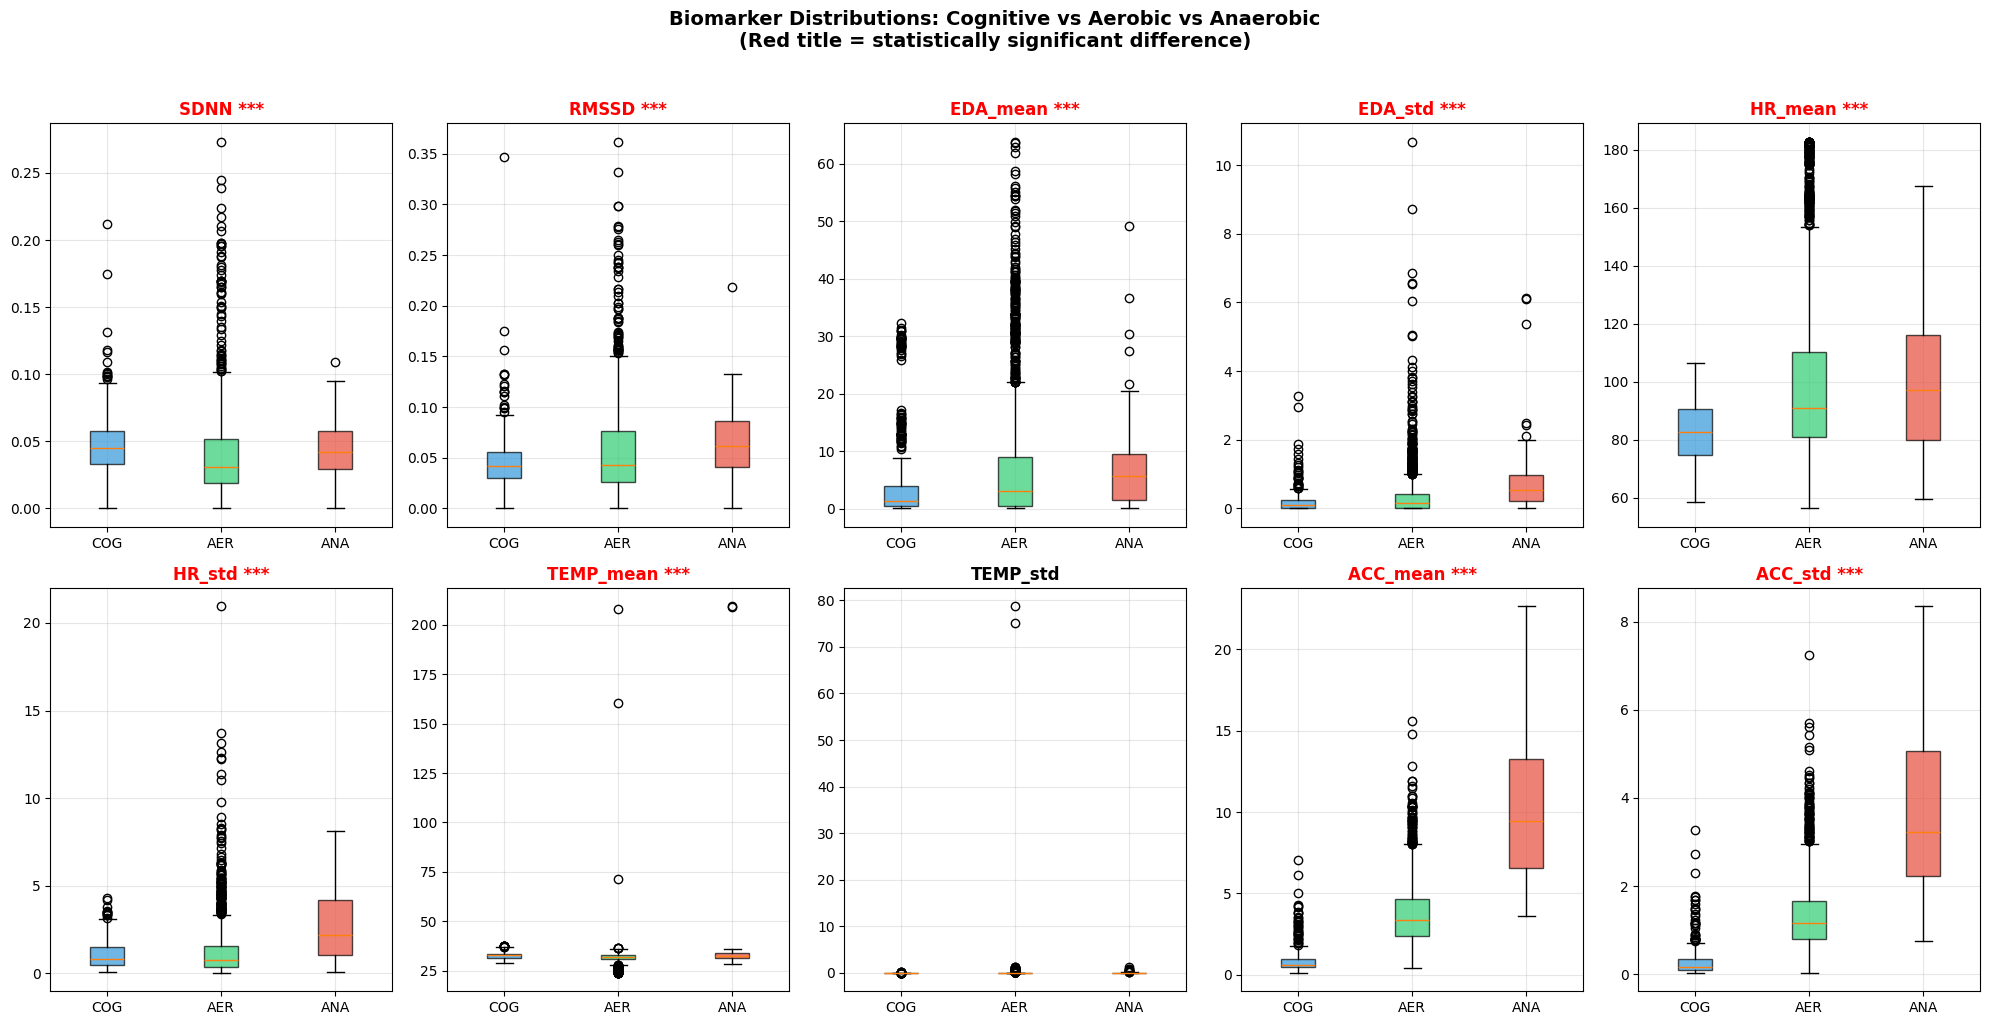

In [12]:
# Box plots comparing distributions
fig, axes = plt.subplots(2, 5, figsize=(20, 10))
axes = axes.flatten()

colors = {'COGNITIVE': '#3498db', 'AEROBIC': '#2ecc71', 'ANAEROBIC': '#e74c3c'}

for i, bio in enumerate(biomarkers):
    ax = axes[i]
    
    # Create box plot data
    data_to_plot = []
    labels = []
    for activity in ['COGNITIVE', 'AEROBIC', 'ANAEROBIC']:
        vals = df_combined[df_combined['activity_type'] == activity][bio].dropna()
        data_to_plot.append(vals)
        labels.append(activity)
    
    bp = ax.boxplot(data_to_plot, labels=['COG', 'AER', 'ANA'], patch_artist=True)
    
    for patch, color in zip(bp['boxes'], [colors['COGNITIVE'], colors['AEROBIC'], colors['ANAEROBIC']]):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    
    ax.set_title(bio, fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)
    
    # Add significance marker if ANOVA was significant
    if bio in significant_biomarkers:
        ax.set_title(f"{bio} ***", fontsize=12, fontweight='bold', color='red')

# Hide empty subplots
for j in range(len(biomarkers), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Biomarker Distributions: Cognitive vs Aerobic vs Anaerobic\n(Red title = statistically significant difference)', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

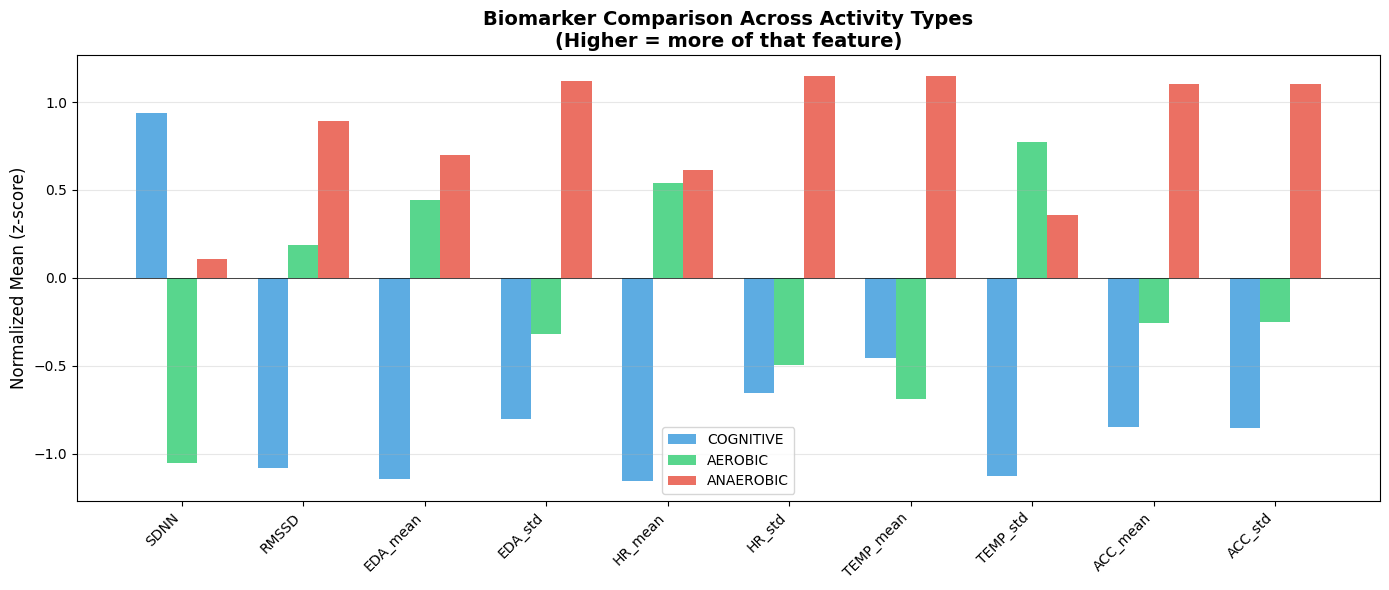

In [13]:
# Mean comparison bar chart
fig, ax = plt.subplots(figsize=(14, 6))

# Normalize means for visualization (z-score across activities)
means_df = df_combined.groupby('activity_type')[biomarkers].mean()
means_normalized = (means_df - means_df.mean()) / means_df.std()

x = np.arange(len(biomarkers))
width = 0.25

bars1 = ax.bar(x - width, means_normalized.loc['COGNITIVE'], width, label='COGNITIVE', color='#3498db', alpha=0.8)
bars2 = ax.bar(x, means_normalized.loc['AEROBIC'], width, label='AEROBIC', color='#2ecc71', alpha=0.8)
bars3 = ax.bar(x + width, means_normalized.loc['ANAEROBIC'], width, label='ANAEROBIC', color='#e74c3c', alpha=0.8)

ax.set_ylabel('Normalized Mean (z-score)', fontsize=12)
ax.set_title('Biomarker Comparison Across Activity Types\n(Higher = more of that feature)', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(biomarkers, rotation=45, ha='right')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)

plt.tight_layout()
plt.show()

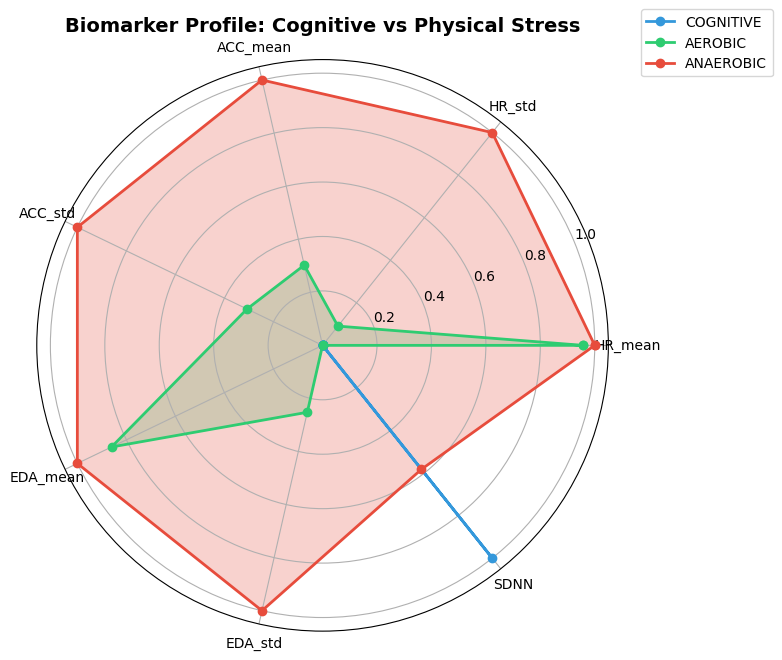

In [14]:
# Radar/Spider chart for each activity type
from math import pi

# Select key biomarkers for radar chart
radar_features = ['HR_mean', 'HR_std', 'ACC_mean', 'ACC_std', 'EDA_mean', 'EDA_std', 'SDNN']
radar_features = [f for f in radar_features if f in df_combined.columns]

# Normalize to 0-1 scale for radar
means = df_combined.groupby('activity_type')[radar_features].mean()
means_norm = (means - means.min()) / (means.max() - means.min())

# Number of variables
N = len(radar_features)
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]  # complete the loop

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

colors = {'COGNITIVE': '#3498db', 'AEROBIC': '#2ecc71', 'ANAEROBIC': '#e74c3c'}

for activity in ['COGNITIVE', 'AEROBIC', 'ANAEROBIC']:
    values = means_norm.loc[activity].values.tolist()
    values += values[:1]  # complete the loop
    
    ax.plot(angles, values, 'o-', linewidth=2, label=activity, color=colors[activity])
    ax.fill(angles, values, alpha=0.25, color=colors[activity])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_features, fontsize=10)
ax.set_title('Biomarker Profile: Cognitive vs Physical Stress', fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

plt.tight_layout()
plt.show()

---
## 4.5 Per-Subject Imputation (Lev's Note)

**Problem with global mean imputation**: Using the overall mean to fill missing HRV values (SDNN, RMSSD) compresses variance and weakens these features' discriminative power.

**Solution**: Impute missing values using each subject's own mean, preserving individual differences.

In [15]:
# PER-SUBJECT IMPUTATION (Levi's Note)
# Instead of using global mean (which compresses variance), use each subject's
# own mean to preserve individual differences in HRV

hrv_features = ['SDNN', 'RMSSD']

print("Missing values BEFORE per-subject imputation:")
print(df_combined[hrv_features].isnull().sum())

# Per-subject imputation for HRV features
for col in hrv_features:
    if col in df_combined.columns:
        # Fill NaN with subject's own mean
        df_combined[col] = df_combined.groupby('subject_id')[col].transform(
            lambda x: x.fillna(x.mean())
        )

# If a subject has ALL NaN values, fall back to global mean
for col in hrv_features:
    if col in df_combined.columns:
        global_mean = df_combined[col].mean()
        df_combined[col] = df_combined[col].fillna(global_mean)

print("\nMissing values AFTER per-subject imputation:")
print(df_combined[hrv_features].isnull().sum())


Missing values BEFORE per-subject imputation:
SDNN     829
RMSSD    829
dtype: int64

Missing values AFTER per-subject imputation:
SDNN     0
RMSSD    0
dtype: int64


---
## 5. Start to build a 3-Class Activity Classifier

**Goal**: Can we classify segments into COGNITIVE, AEROBIC, or ANAEROBIC based on biomarkers alone?

In [16]:
#classification for activity type based on biomarkers
feature_cols = [c for c in biomarkers if c in df_combined.columns]

X = df_combined[feature_cols]
y = df_combined['activity_type']

# Encode labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print(f"Features used: {feature_cols}")
print(f"Classes: {le.classes_}")
print(f"Class distribution: {dict(zip(le.classes_, np.bincount(y_encoded)))}")

Features used: ['SDNN', 'RMSSD', 'EDA_mean', 'EDA_std', 'HR_mean', 'HR_std', 'TEMP_mean', 'TEMP_std', 'ACC_mean', 'ACC_std']
Classes: ['AEROBIC' 'ANAEROBIC' 'COGNITIVE']
Class distribution: {'AEROBIC': np.int64(1968), 'ANAEROBIC': np.int64(68), 'COGNITIVE': np.int64(413)}


In [17]:
# 3-CLASS ACTIVITY CLASSIFIER WITH LOSO VALIDATION (Essie's Note)

# Using Leave-One-Subject-Out (LOSO) cross-validation instead of random CV
# This gives realistic accuracy for new users (no data leakage between subjects)

from sklearn.ensemble import AdaBoostClassifier
from sklearn.svm import SVC

# Get subject IDs for LOSO
subjects = df_combined['subject_id'].values

classifiers = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'AdaBoost': AdaBoostClassifier(n_estimators=100, random_state=42),
    'SVM (RBF)': SVC(kernel='rbf', random_state=42)
}

print("3-CLASS ACTIVITY CLASSIFIER COMPARISON")
print(f"Task: Classify COGNITIVE vs AEROBIC vs ANAEROBIC")
print(f"Validation: LOSO (Leave-One-Subject-Out) - realistic accuracy for new users")
print(f"{'='*70}\n")

# Use LOSO cross-validation
logo = LeaveOneGroupOut()
print(f"Number of subjects (folds): {logo.get_n_splits(X, y_encoded, subjects)}")
print()

results = []

for clf_name, clf in classifiers.items():
    pipeline = make_pipeline(
        StandardScaler(),  # No SimpleImputer needed - we did per-subject imputation already
        clf
    )
    
    # LOSO cross-validation
    cv_scores = cross_val_score(pipeline, X, y_encoded, cv=logo, groups=subjects, scoring='accuracy')
    
    print(f"{clf_name:20}: {cv_scores.mean():.3f} (+/- {cv_scores.std()*2:.3f})")
    
    results.append({
        'Classifier': clf_name,
        'CV Accuracy': cv_scores.mean(),
        'CV Std': cv_scores.std(),
        'CV Method': 'LOSO'
    })

df_results = pd.DataFrame(results)
best = df_results.loc[df_results['CV Accuracy'].idxmax()]
print(f"\nBEST: {best['Classifier']} with {best['CV Accuracy']:.1%} LOSO accuracy")

3-CLASS ACTIVITY CLASSIFIER COMPARISON
Task: Classify COGNITIVE vs AEROBIC vs ANAEROBIC
Validation: LOSO (Leave-One-Subject-Out) - realistic accuracy for new users

Number of subjects (folds): 22

Random Forest       : 0.913 (+/- 0.132)
Gradient Boosting   : 0.908 (+/- 0.140)
AdaBoost            : 0.853 (+/- 0.221)
SVM (RBF)           : 0.907 (+/- 0.138)

BEST: Random Forest with 91.3% LOSO accuracy


Note: LOSO accuracy is typically LOWER than random CV but more realistic 
This represents expected performance on a completely new user

Classification Report:

              precision    recall  f1-score   support

     AEROBIC       0.96      0.98      0.97       394
   ANAEROBIC       0.83      0.38      0.53        13
   COGNITIVE       0.93      0.90      0.91        83

    accuracy                           0.95       490
   macro avg       0.91      0.76      0.80       490
weighted avg       0.95      0.95      0.95       490



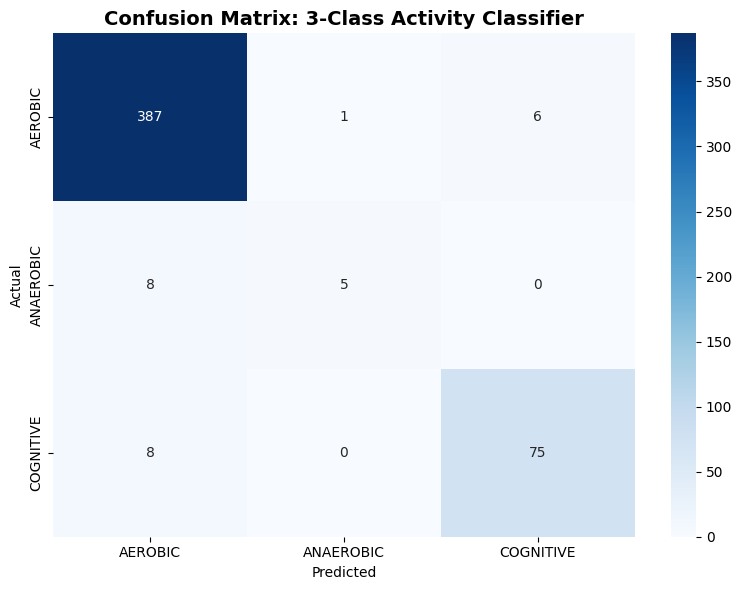

In [18]:
# Train best model and show confusion matrix
from sklearn.model_selection import train_test_split

# Use Random Forest
best_pipeline = make_pipeline(
    SimpleImputer(strategy='mean'),
    StandardScaler(),
    RandomForestClassifier(n_estimators=100, random_state=42)
)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

best_pipeline.fit(X_train, y_train)
y_pred = best_pipeline.predict(X_test)

# Classification report
print("Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix: 3-Class Activity Classifier', fontsize=14, fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

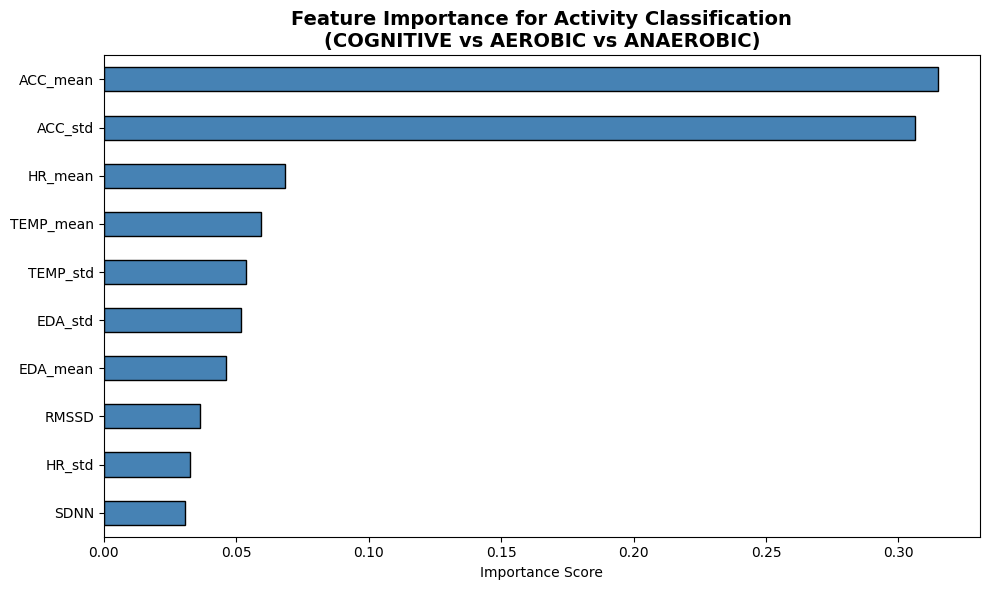


Top 5 Most Important Features for Activity Classification:
  ACC_mean: 0.315
  ACC_std: 0.306
  HR_mean: 0.068
  TEMP_mean: 0.059
  TEMP_std: 0.054


In [19]:
# Feature importance for activity classification
rf_model = best_pipeline.named_steps['randomforestclassifier']
importances = pd.Series(rf_model.feature_importances_, index=feature_cols)

plt.figure(figsize=(10, 6))
importances.sort_values().plot(kind='barh', color='steelblue', edgecolor='black')
plt.title('Feature Importance for Activity Classification\n(COGNITIVE vs AEROBIC vs ANAEROBIC)', 
          fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print("\nTop 5 Most Important Features for Activity Classification:")
for feat, imp in importances.sort_values(ascending=False).head(5).items():
    print(f"  {feat}: {imp:.3f}")

---
## 6. Summary of findings

In [ ]:
print("BIOMARKER COMPARISON SUMMARY")
print("="*70)

print("\n1. STATISTICALLY SIGNIFICANT DIFFERENCES (ANOVA p < 0.05):")
for _, row in df_anova[df_anova['significant']].iterrows():
    print(f"   - {row['biomarker']}: F={row['f_stat']:.2f}, p={row['p_value']:.6f}")

print("\n2. KEY DISTINGUISHING FEATURES:")
print("   Features that best separate COGNITIVE from PHYSICAL stress:")
for feat, imp in importances.sort_values(ascending=False).head(3).items():
    print(f"   - {feat} (importance: {imp:.3f})")

print(f"\n3. ACTIVITY CLASSIFIER PERFORMANCE:")
print(f"   Best model: {best['Classifier']}")
print(f"   Accuracy: {best['CV Accuracy']:.1%}")

---
## 7. Apple Watch feature model

**Note**: Apple Watch does not have EDA (electrodermal activity) or skin temperature sensors.

**Available Features on Apple Watch**:
- HR (Heart Rate) → `HR_mean`, `HR_std`
- HRV → `SDNN`, `RMSSD` 
- ACC (Accelerometer) → `ACC_mean`, `ACC_std`

**Excluded Features**:
- ~~EDA_mean, EDA_std~~ (no EDA sensor)
- ~~TEMP_mean, TEMP_std~~ (no skin temperature sensor)

In [25]:
# APPLE WATCH COMPATIBLE MODEL
# Only uses features available on Apple Watch: HR, HRV (SDNN, RMSSD), ACC

apple_watch_features = ['HR_mean', 'HR_std', 'SDNN', 'RMSSD', 'ACC_mean', 'ACC_std']

# Verify all features exist
apple_watch_features = [f for f in apple_watch_features if f in df_combined.columns]
print(f"Apple Watch Features: {apple_watch_features}")
print(f"Excluded Features: EDA_mean, EDA_std, TEMP_mean, TEMP_std")
print()

# Prepare data with Apple Watch features only
X_apple = df_combined[apple_watch_features]
y_apple = df_combined['activity_type']
subjects_apple = df_combined['subject_id'].values

# Encode labels
y_apple_encoded = le.fit_transform(y_apple)
print(f"Task: Classify COGNITIVE vs AEROBIC vs ANAEROBIC")
print(f"Features: {len(apple_watch_features)} (vs {len(feature_cols)} with all sensors)")
print(f"Validation: LOSO (Leave-One-Subject-Out)")
print(f"{'='*70}\n")

# Run classifiers with LOSO
logo_apple = LeaveOneGroupOut()
results_apple = []

for clf_name, clf in classifiers.items():
    pipeline = make_pipeline(
        StandardScaler(),
        clf
    )
    
    # LOSO cross-validation
    cv_scores = cross_val_score(pipeline, X_apple, y_apple_encoded, 
                                 cv=logo_apple, groups=subjects_apple, scoring='accuracy')
    
    print(f"{clf_name:20}: {cv_scores.mean():.3f} (+/- {cv_scores.std()*2:.3f})")
    
    results_apple.append({
        'Classifier': clf_name,
        'CV Accuracy': cv_scores.mean(),
        'CV Std': cv_scores.std(),
        'Features': 'Apple Watch'
    })

df_results_apple = pd.DataFrame(results_apple)
best_apple = df_results_apple.loc[df_results_apple['CV Accuracy'].idxmax()]
print(f"\nBEST (Apple Watch): {best_apple['Classifier']} with {best_apple['CV Accuracy']:.1%} LOSO accuracy")

# Compare to full feature set
print("COMPARISON: Apple Watch vs Full Sensor Set")
print(f"{'='*70}")
print(f"Full Sensors (10 features):    {best['CV Accuracy']:.1%} accuracy")
print(f"Apple Watch Only (6 features): {best_apple['CV Accuracy']:.1%} accuracy")
print(f"Accuracy Drop:                 {(best['CV Accuracy'] - best_apple['CV Accuracy'])*100:.1f} percentage points")

Apple Watch Features: ['HR_mean', 'HR_std', 'SDNN', 'RMSSD', 'ACC_mean', 'ACC_std']
Excluded Features: EDA_mean, EDA_std, TEMP_mean, TEMP_std

Task: Classify COGNITIVE vs AEROBIC vs ANAEROBIC
Features: 6 (vs 10 with all sensors)
Validation: LOSO (Leave-One-Subject-Out)

Random Forest       : 0.913 (+/- 0.122)
Gradient Boosting   : 0.905 (+/- 0.123)
AdaBoost            : 0.845 (+/- 0.149)
SVM (RBF)           : 0.918 (+/- 0.111)

BEST (Apple Watch): SVM (RBF) with 91.8% LOSO accuracy
COMPARISON: Apple Watch vs Full Sensor Set
Full Sensors (10 features):    91.3% accuracy
Apple Watch Only (6 features): 91.8% accuracy
Accuracy Drop:                 -0.5 percentage points


APPLE WATCH Features only MODEL - Classification Report:

              precision    recall  f1-score   support

     AEROBIC       0.95      0.97      0.96       394
   ANAEROBIC       1.00      0.46      0.63        13
   COGNITIVE       0.86      0.87      0.86        83

    accuracy                           0.94       490
   macro avg       0.94      0.77      0.82       490
weighted avg       0.94      0.94      0.94       490



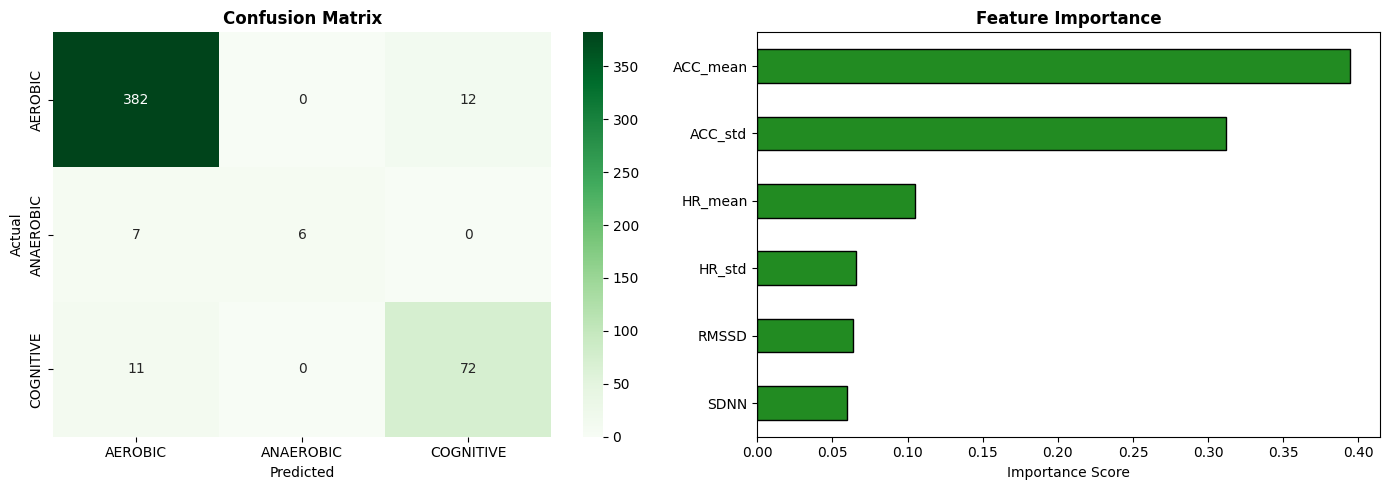


Feature Importance Ranking:
  1. ACC_mean: 0.395
  2. ACC_std: 0.312
  3. HR_mean: 0.105
  4. HR_std: 0.066
  5. RMSSD: 0.063
  6. SDNN: 0.060


In [ ]:
# Apple Watch features only : Confusion Matrix and Feature Importance
# Train 
best_pipeline_apple = make_pipeline(
    SimpleImputer(strategy='mean'),
    StandardScaler(),
    RandomForestClassifier(n_estimators=100, random_state=42)
)

# Train/test split
X_train_apple, X_test_apple, y_train_apple, y_test_apple = train_test_split(
    X_apple, y_apple_encoded, test_size=0.2, random_state=42, stratify=y_apple_encoded
)

best_pipeline_apple.fit(X_train_apple, y_train_apple)
y_pred_apple = best_pipeline_apple.predict(X_test_apple)

# Classification report
print("APPLE WATCH Features only MODEL - Classification Report:\n")
print(classification_report(y_test_apple, y_pred_apple, target_names=le.classes_))

# Create side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
cm_apple = confusion_matrix(y_test_apple, y_pred_apple)
sns.heatmap(cm_apple, annot=True, fmt='d', cmap='Greens',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=axes[0])
axes[0].set_title('Confusion Matrix', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Feature importance
rf_model_apple = best_pipeline_apple.named_steps['randomforestclassifier']
importances_apple = pd.Series(rf_model_apple.feature_importances_, index=apple_watch_features)
importances_apple.sort_values().plot(kind='barh', color='forestgreen', edgecolor='black', ax=axes[1])
axes[1].set_title('Feature Importance', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Importance Score')

plt.tight_layout()
plt.show()

print("\nFeature Importance Ranking:")
for i, (feat, imp) in enumerate(importances_apple.sort_values(ascending=False).items(), 1):
    print(f"  {i}. {feat}: {imp:.3f}")

# Notes for next steps